In [1]:
import os
if "KERAS_BACKEND" not in os.environ:
    os.environ["KERAS_BACKEND"] = "torch"

import math
import numpy as np
import seaborn as sns
import pandas as pd
import keras
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import truncnorm
from numba import njit
import bayesflow as bf

from ddmc import DDMC, helpers, hddmc_simulator

INFO:bayesflow:Using backend 'torch'
When using torch backend, we need to disable autograd by default to avoid excessive memory usage. Use

with torch.enable_grad():
    ...

in contexts where you need gradients (e.g. custom training loops).


#### Priors

In [2]:
global_prior = {
    'mu_t0'     : (360.0, 50.0),
    'mu_muc'    : (0.4, 0.1),
    'mu_b'      : (55, 15),
    'mu_A1'     : (20, 8),
    'mu_A2'     : (20, 8),
    'mu_tau1' : ([30, 180], 15),
    'mu_tau2' : ([30, 180], 15),

    'log_sigma_t0'  : (3.5, 0.3),
    'log_sigma_muc' : (-1.7, 0.5),
    'log_sigma_b'   : (2.3, 0.4),
    'log_sigma_A1'  : (1.6, 0.5),
    'log_sigma_A2'  : (1.6, 0.5),
    'log_sigma_tau1': (3.0, 0.5),
    'log_sigma_tau2': (3.0, 0.5)
}

print(np.exp(global_prior['log_sigma_t0']))
print(np.exp(global_prior['log_sigma_muc']))
print(np.exp(global_prior['log_sigma_b']))
print(np.exp(global_prior['log_sigma_A1']))
print(np.exp(global_prior['log_sigma_A2']))
print(np.exp(global_prior['log_sigma_tau1']))
print(np.exp(global_prior['log_sigma_tau2']))

[33.11545196  1.34985881]
[0.18268352 1.64872127]
[9.97418245 1.4918247 ]
[4.95303242 1.64872127]
[4.95303242 1.64872127]
[20.08553692  1.64872127]
[20.08553692  1.64872127]


#### Load Trained Models

In [3]:
# Load trained models
##note: preliminary; TODO
#approximator_global = keras.saving.load_model("out/1106-global.keras")
#approximator_local = keras.saving.load_model("out/1106-local.keras")
#approximator_global = keras.saving.load_model("out/HDDMC_GLOBAL_500.keras")
#approximator_local = keras.saving.load_model("out/HDDMC_LOCAL_500.keras")
approximator_global = keras.saving.load_model("out/HDDMC_GLOBAL_300_U.keras")
approximator_local = keras.saving.load_model("out/HDDMC_LOCAL_300_U.keras")


#### Load Empirical Data

In [4]:
directory_1a = "../data/ReyMermetGade2016/Exp1a_data/combi/"      # Flanker x Stroop
directory_1b = "../data/ReyMermetGade2016/Exp1b_data/combi/"      # Flanker x Stroop
directory_1c = "../data/ReyMermetGade2016/Exp1c_data/combi/"      # Flanker x Stroop
directory_2 = "../data/ReyMermetGade2016/Exp2_data/combi/"        # Simon x Stroop
directory_3 = "../data/ReyMermetGade2016/Exp3_data/combi/"        # Flanker x Simon

colnames_1a = [
    "subject", "block", "catch", "stimulus", "stimuluscolor", "flankercolor", 
    "flanker", "stroop", "xr", "resp", "corr", "rt", "re"
]
colnames_1b = [
    "subject", "block", "catch", "stimulus", "stimuluscolor", "flankercolor", 
    "flanker", "stroop", "stroopstimulusnumber", "flankerstimulusnumber", 
    "stimulusnumber", "xr", "resp", "corr", "rt", "re"
]
colnames_1c = [
    "subject", "block", "trial", "catch", "stimulus", "stimuluscolor", 
    "flankercolor", "flanker", "stroop", "xr", "resp", "corr", "rt", "re"
]
colnames_2 = [
    "subject", "block", "catch", "stimulus", "stimuluscolor", 
    "stimulusposition", "simon", "stroop", "xr", "resp", "corr", "rt", "re"
]
colnames_3 = [
    "subject", "block", "stimulus", "flankercolor", "stimulusposition", 
    "simon", "flanker", "xr", "resp", "corr", "rt", "re"
]

df_1a = helpers.read_ReyMermetGade(
    directory_1a, colnames_1a, "flanker", "stroop"
)
df_1b = helpers.read_ReyMermetGade(
   directory_1b,  colnames_1b, "flanker", "stroop"
)
df_1c = helpers.read_ReyMermetGade(
    directory_1c, colnames_1c, "flanker", "stroop"
)
df_2 = helpers.read_ReyMermetGade(
    directory_2, colnames_2, "simon", "stroop"
)
df_3 = helpers.read_ReyMermetGade(
    directory_3, colnames_3, "simon", "flanker"
)

#print(df_3)
#print(df_2)
#print(df_1a)
#print(df_1b)
#print(df_1c)

#### Get posterior samples for the subject-level parameters

In [5]:
local_posterior_1a = helpers.fit_empirical_data(
    data=df_1a, approximator_global=approximator_global, 
    approximator_local=approximator_local, priors=global_prior, 
    num_samples=100, id_name="id", rt="rt", accuracy="corr", 
    congruency="condition", subject_level=True
) 
local_posterior_2 = helpers.fit_empirical_data(
    data=df_2, approximator_global=approximator_global, 
    approximator_local=approximator_local, priors=global_prior, 
    num_samples=100, id_name="id", rt="rt", accuracy="corr", 
    congruency="condition", subject_level=True
) 
local_posterior_3 = helpers.fit_empirical_data(
    data=df_3, approximator_global=approximator_global, 
    approximator_local=approximator_local, priors=global_prior, 
    num_samples=100, id_name="id", rt="rt", accuracy="corr", 
    congruency="condition", subject_level=True
) 

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

...

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

#### Resimulate

In [6]:
simulator = DDMC(global_prior=global_prior, contamination_probability=0)

In [7]:
resim_data_1a = helpers.resim_data(
    empirical_data=df_1a, post_samples=local_posterior_1a, simulator=simulator, 
    id_name="id", num_resims=100, n_resim_trials=8
)
resim_data_2 = helpers.resim_data(
    empirical_data=df_2, post_samples=local_posterior_2, simulator=simulator, 
    id_name="id", num_resims=100, n_resim_trials=8
)
resim_data_3 = helpers.resim_data(
    empirical_data=df_3, post_samples=local_posterior_3, simulator=simulator, 
    id_name="id", num_resims=100, n_resim_trials=8
)

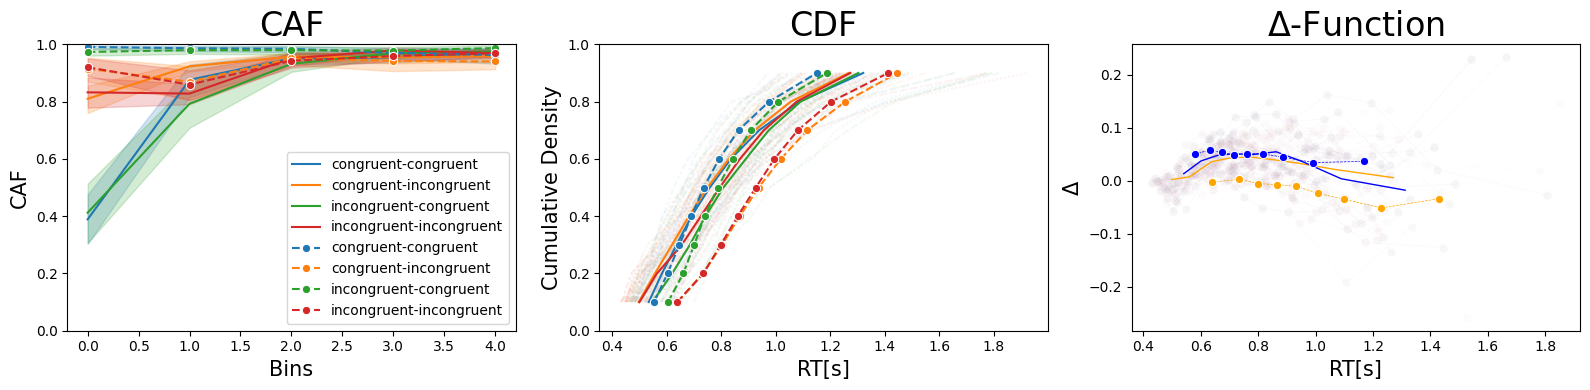

In [ ]:
delta_resim_1a, cdf_resim_1a, caf_resim_1a = helpers.ddmc_stats(
    resim_data_1a, id_name="subj_id", accuracy="corr", congruency="congruency"
)

delta_1a, cdf_1a, caf_1a = helpers.ddmc_stats(
    df_1a, id_name="id", accuracy="corr", congruency="CI"
)

helpers.plot_stats(
    delta_data=delta_resim_1a, cdf_data=cdf_resim_1a, caf_data=caf_resim_1a, 
    delta_data_2=delta_1a, cdf_data_2=cdf_1a, caf_data_2=caf_1a, 
    accuracy="corr", id_name="subj_id", accuracy_2="corr", congruency_2="CI"
); 

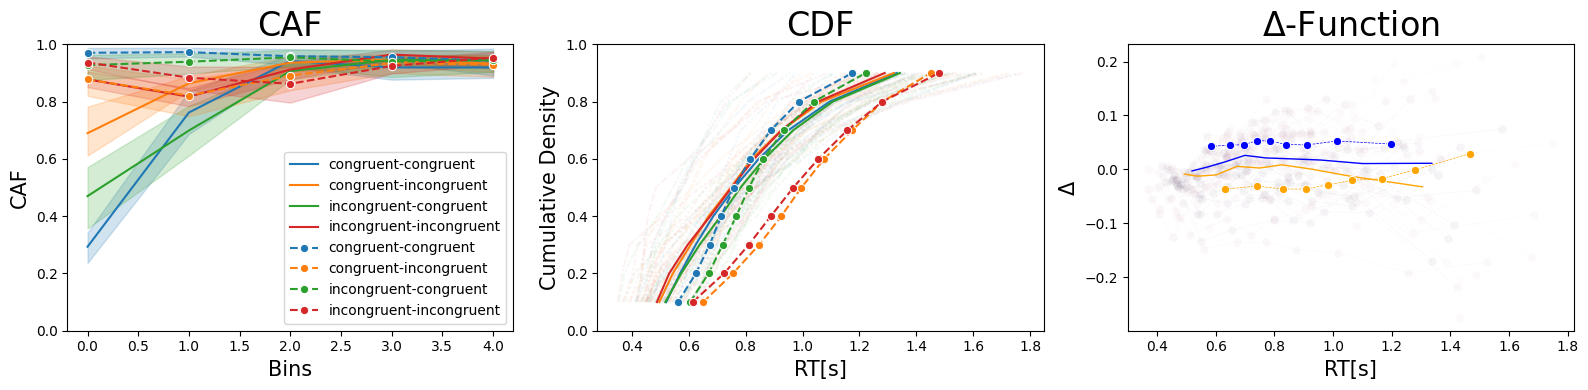

In [13]:
delta_resim_2, cdf_resim_2, caf_resim_2 = helpers.ddmc_stats(
    resim_data_2, id_name="subj_id", accuracy="corr", congruency="congruency"
)

delta_2, cdf_2, caf_2 = helpers.ddmc_stats(
    df_2, id_name="id", accuracy="corr", congruency="CI"
)

helpers.plot_stats(
    delta_data=delta_resim_2, cdf_data=cdf_resim_2, caf_data=caf_resim_2, 
    delta_data_2=delta_2, cdf_data_2=cdf_2, caf_data_2=caf_2, 
    accuracy="corr", id_name="subj_id", accuracy_2="corr", congruency_2="CI"
); 

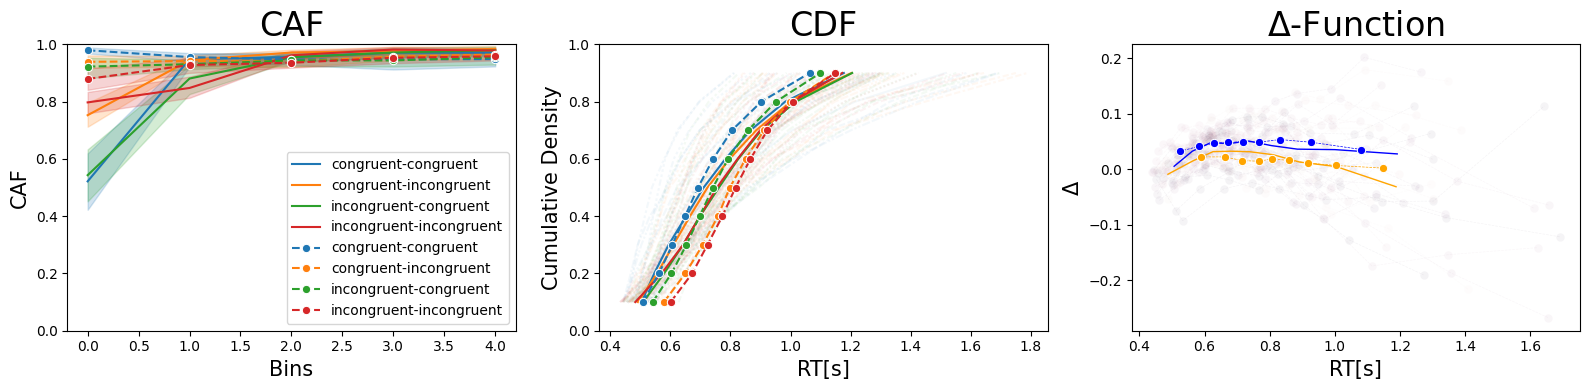

In [14]:
delta_resim_3, cdf_resim_3, caf_resim_3 = helpers.ddmc_stats(
    resim_data_3, id_name="subj_id", accuracy="corr", congruency="congruency"
)

delta_3, cdf_3, caf_3 = helpers.ddmc_stats(
    df_3, id_name="id", accuracy="corr", congruency="CI"
)

helpers.plot_stats(
    delta_data=delta_resim_3, cdf_data=cdf_resim_3, caf_data=caf_resim_3, 
    delta_data_2=delta_3, cdf_data_2=cdf_3, caf_data_2=caf_3, 
    accuracy="corr", id_name="subj_id", accuracy_2="corr", congruency_2="CI"
); 

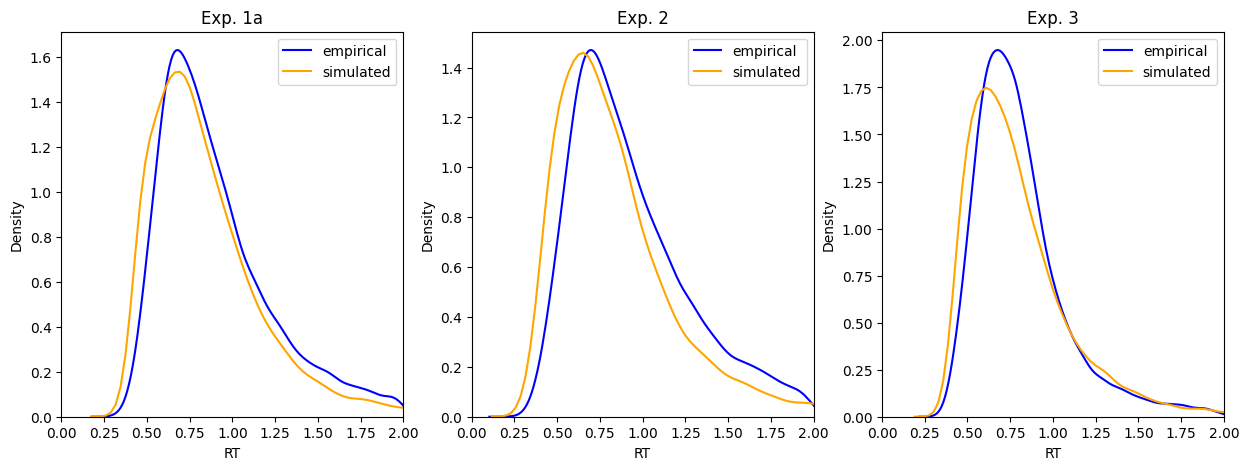

In [15]:
f, ax = plt.subplots(1, 3, figsize=(15, 5))

plt.sca(ax=ax[0])
helpers.plot_rts(
    data=df_1a, data_2=resim_data_1a, 
    label="empirical", label_2="simulated", 
    accuracy="corr", accuracy_2="corr", 
    exclude_errors=True, 
    panel_header="Exp. 1a", 
); 

plt.sca(ax=ax[1])
helpers.plot_rts(
    data=df_2, data_2=resim_data_2, 
    label="empirical", label_2="simulated", 
    accuracy="corr", accuracy_2="corr", 
    exclude_errors=True, 
    panel_header="Exp. 2"
); 

plt.sca(ax=ax[2])
helpers.plot_rts(
    data=df_3, data_2=resim_data_3, 
    label="empirical", label_2="simulated", 
    accuracy="corr", accuracy_2="corr", 
    exclude_errors=True, 
    panel_header="Exp. 3"
); 

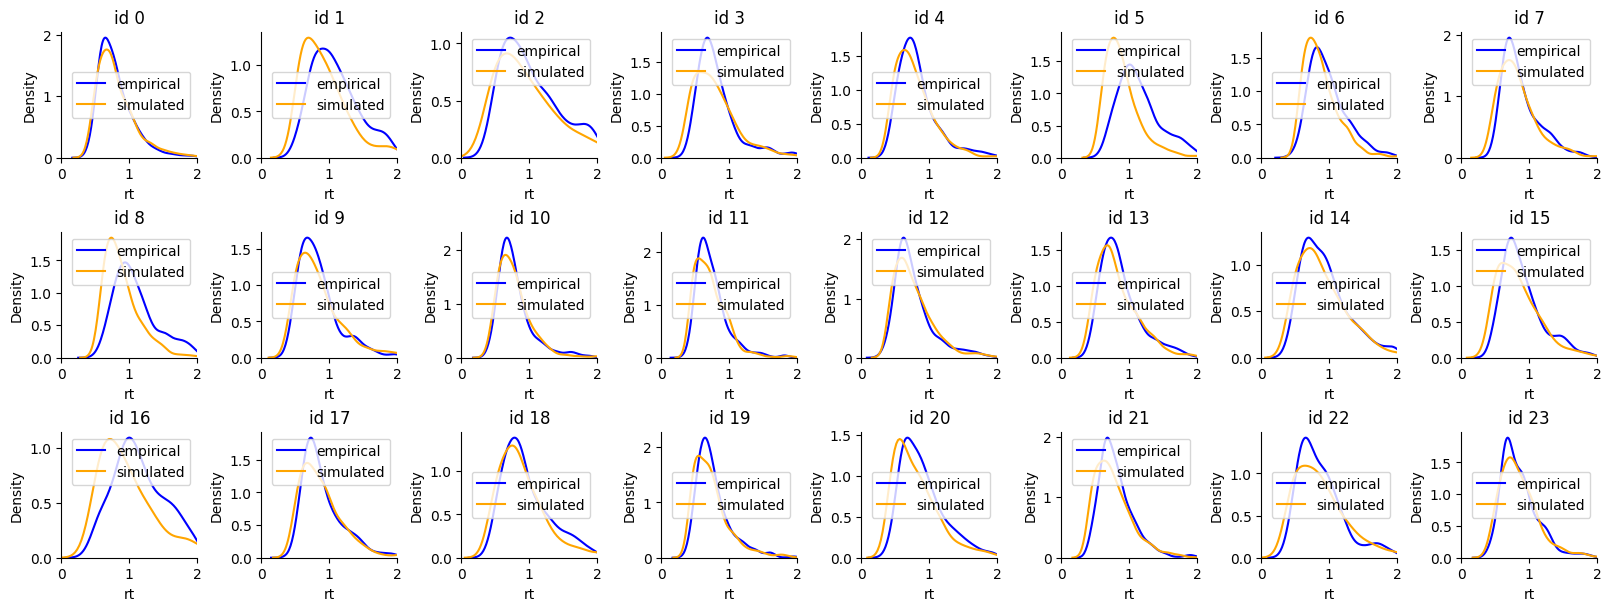

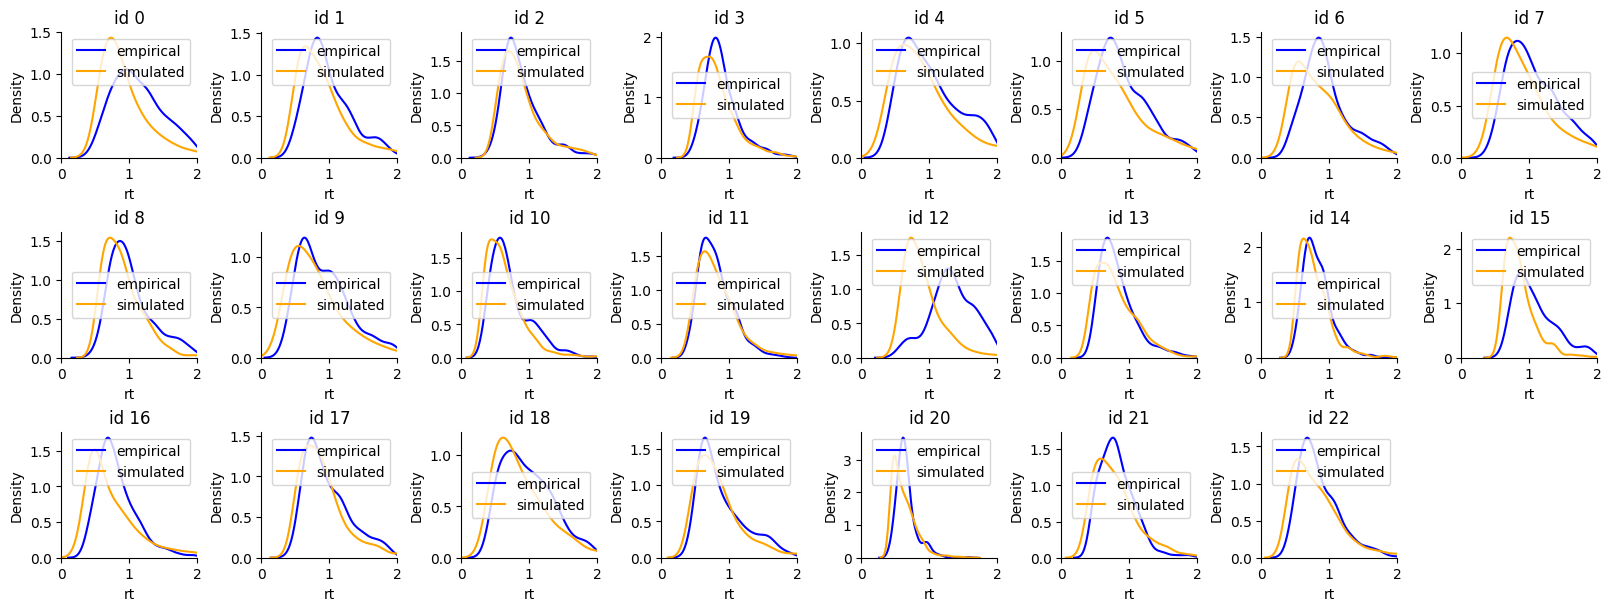

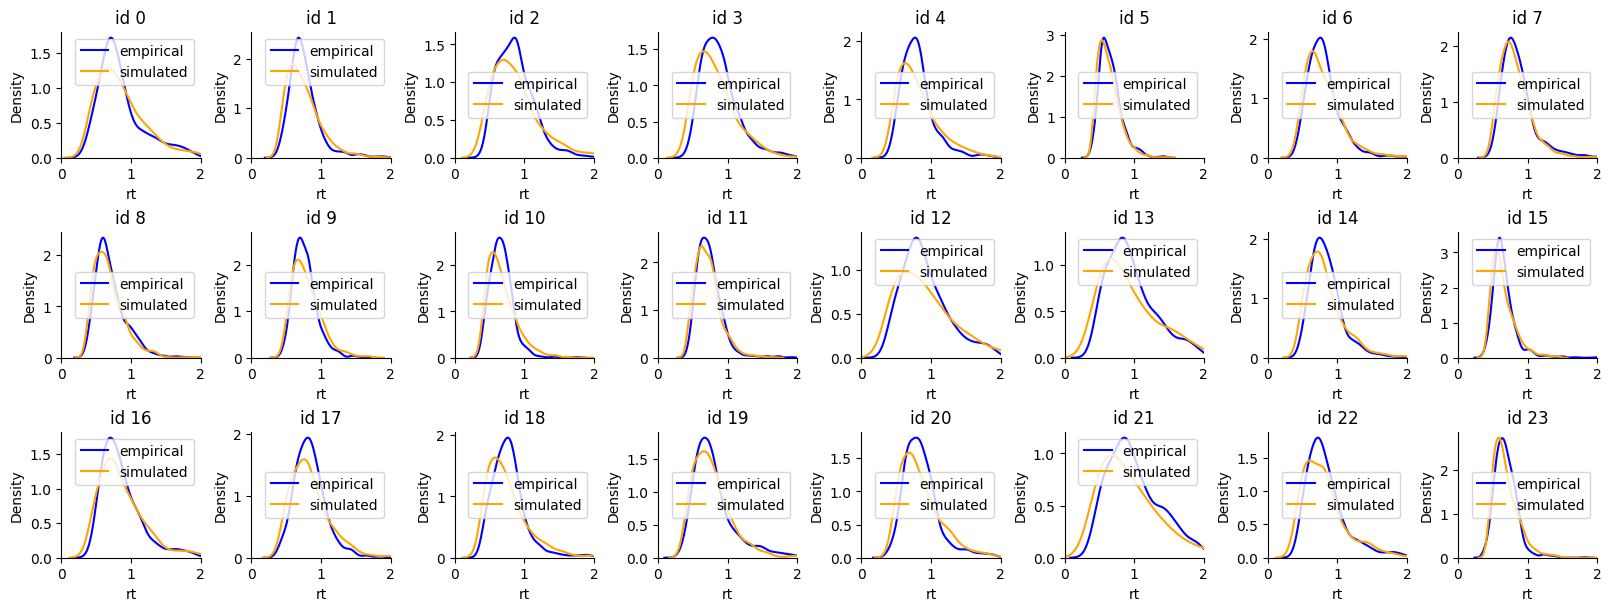

In [16]:
helpers.plot_rts(
    data=df_1a, data_2=resim_data_1a, label="empirical", label_2="simulated", 
    accuracy="corr", accuracy_2="corr", id_col="id", id_col_2="subj_id", 
    n_rows=3, exclude_errors=True
); 

helpers.plot_rts(
    data=df_2, data_2=resim_data_2, label="empirical", label_2="simulated", 
    accuracy="corr", accuracy_2="corr", id_col="id", id_col_2="subj_id", 
    n_rows=3, exclude_errors=True
); 

helpers.plot_rts(
    data=df_3, data_2=resim_data_3, label="empirical", label_2="simulated", 
    accuracy="corr", accuracy_2="corr", id_col="id", id_col_2="subj_id", 
    n_rows=3, exclude_errors=True 
); 

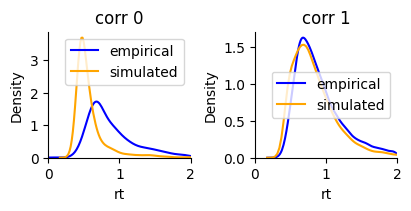

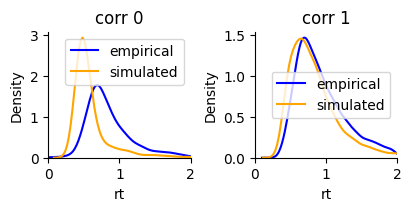

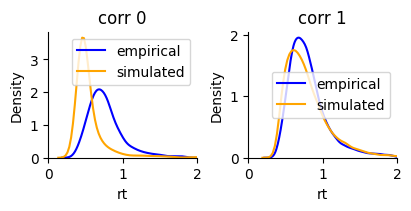

In [17]:
helpers.plot_rts(
    data=df_1a, data_2=resim_data_1a, label="empirical", label_2="simulated", 
    accuracy="corr", accuracy_2="corr", id_col="corr", id_col_2="corr", 
    n_rows=1, exclude_errors=False
); 

helpers.plot_rts(
    data=df_2, data_2=resim_data_2, label="empirical", label_2="simulated", 
    accuracy="corr", accuracy_2="corr", id_col="corr", id_col_2="corr", 
    n_rows=1, exclude_errors=False
); 

helpers.plot_rts(
    data=df_3, data_2=resim_data_3, label="empirical", label_2="simulated", 
    accuracy="corr", accuracy_2="corr", id_col="corr", id_col_2="corr", 
    n_rows=1, exclude_errors=False
); 

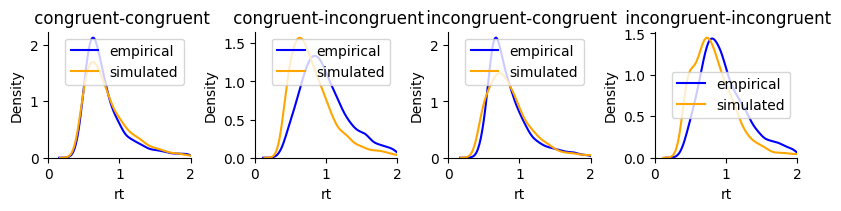

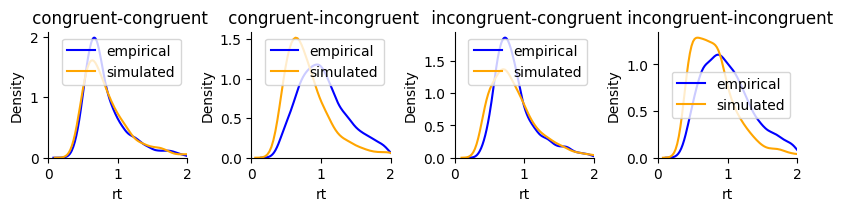

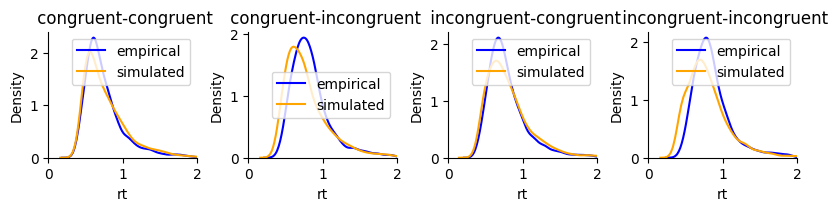

In [19]:
helpers.plot_rts(
    data=df_1a, data_2=resim_data_1a, label="empirical", label_2="simulated", 
    accuracy="corr", accuracy_2="corr", id_col="CI", id_col_2="congruency", 
    n_rows=1, exclude_errors=True, panel_header=""
); 

helpers.plot_rts(
    data=df_2, data_2=resim_data_2, label="empirical", label_2="simulated", 
    accuracy="corr", accuracy_2="corr", id_col="CI", id_col_2="congruency", 
    n_rows=1, exclude_errors=True, panel_header=""
); 

helpers.plot_rts(
    data=df_3, data_2=resim_data_3, label="empirical", label_2="simulated", 
    accuracy="corr", accuracy_2="corr", id_col="CI", id_col_2="congruency", 
    n_rows=1, exclude_errors=True, panel_header=""
); 

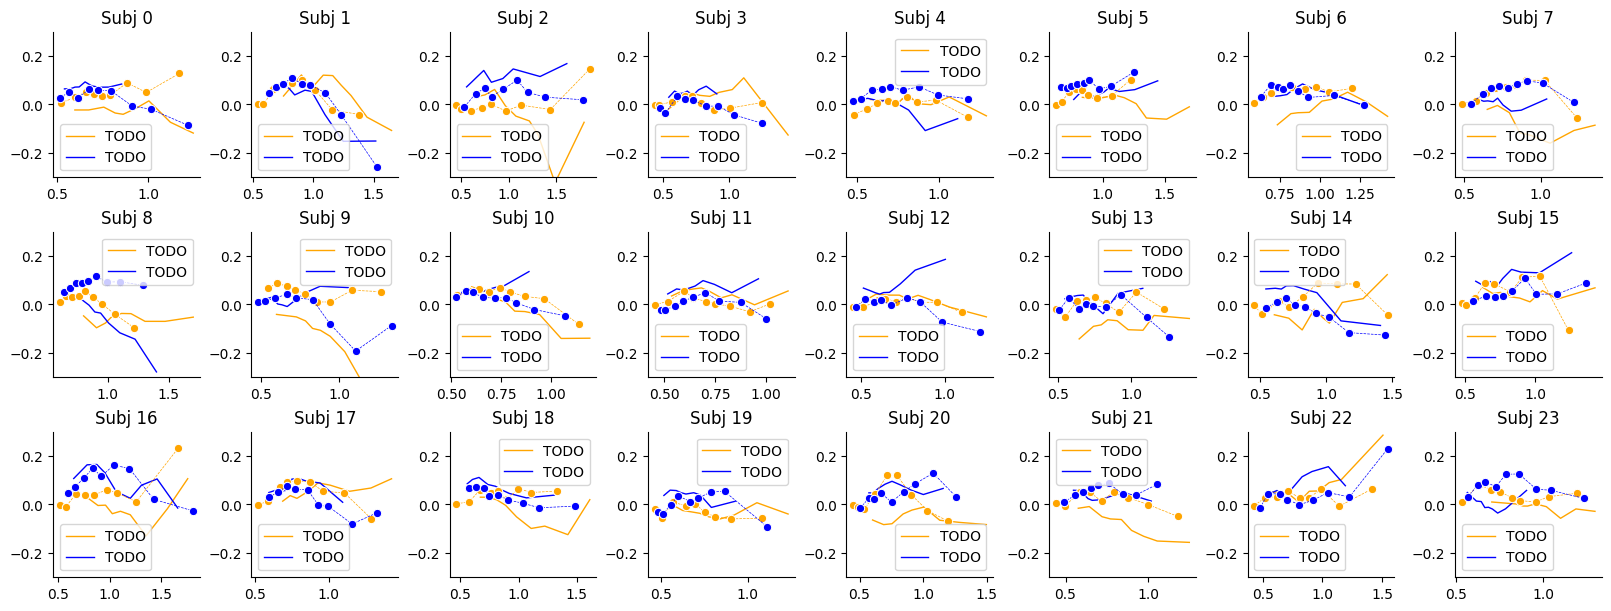

In [148]:
helpers.plot_subj_stats(
    data_1=delta_1a, data_2=delta_resim_1a, 
    id_col_1="id", id_col_2="subj_id", 
    delta_ylim=(-0.3, 0.3), plot_type="delta"
); 

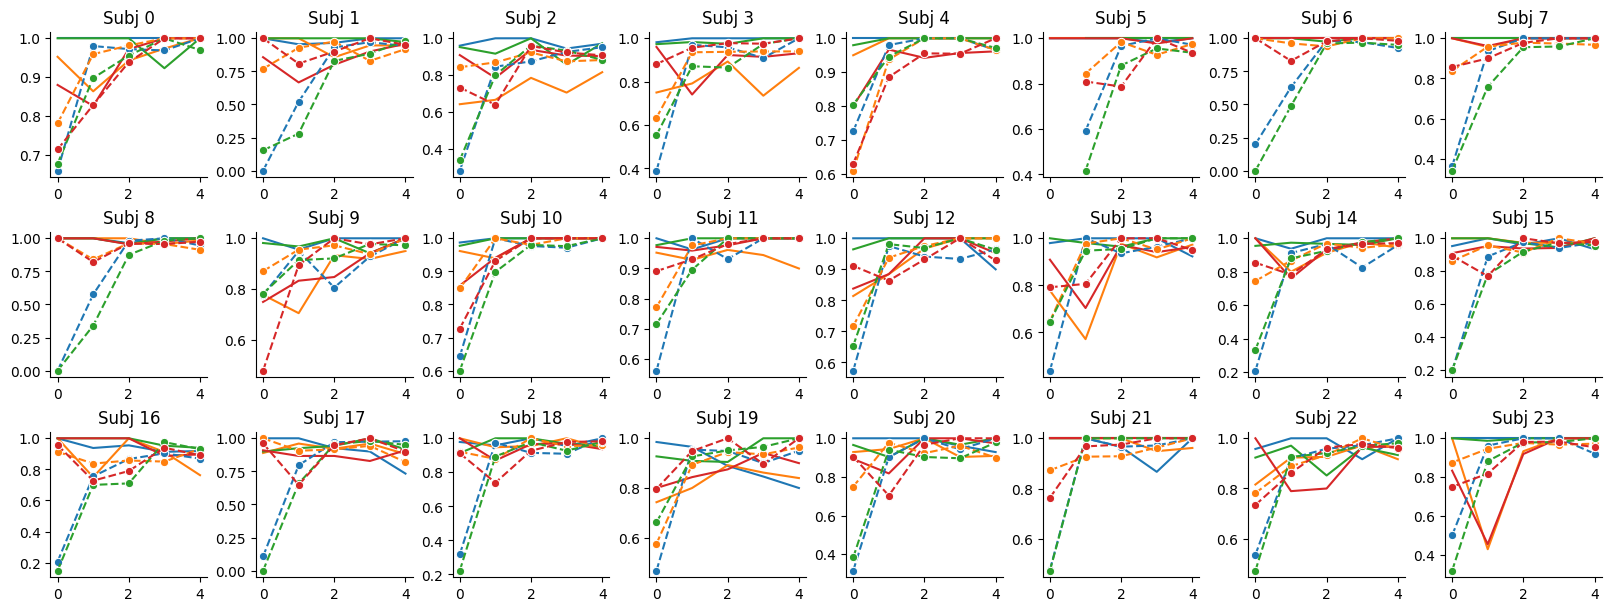

In [145]:
helpers.plot_subj_stats(
    data_1=caf_1a, data_2=caf_resim_1a, 
    id_col_1="id", id_col_2="subj_id", 
    accuracy_1="corr", accuracy_2="corr", 
    congruency_1="CI", congruency_2="congruency", 
    plot_type="caf"
); 

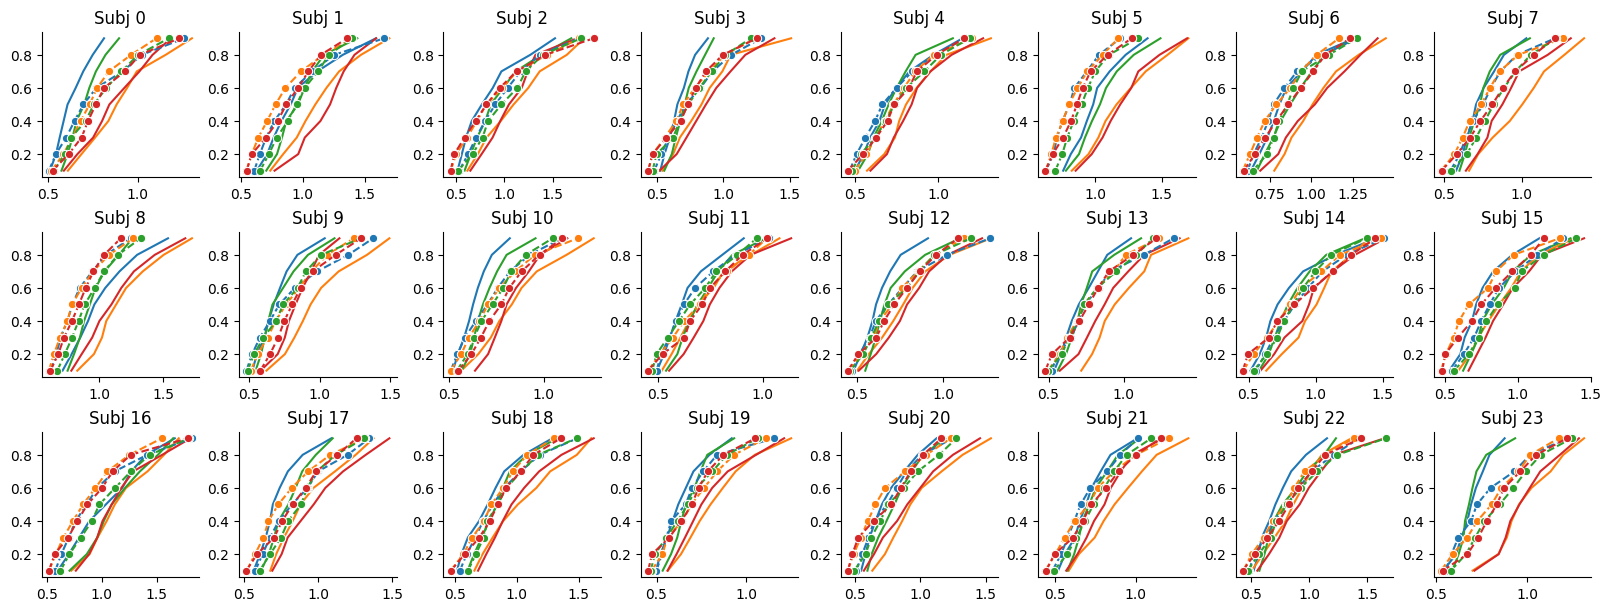

In [142]:
helpers.plot_subj_stats(
    data_1=cdf_1a, data_2=cdf_resim_1a, 
    id_col_1="id", id_col_2="subj_id", 
    congruency_1="CI", congruency_2="congruency", 
    plot_type="cdf"
); 